Conversion rate for Version A: 0.2023
Conversion rate for Version B: 0.2215
T-statistic: -5.2439
P-value: 0.0000
The result is statistically significant, meaning there is a significant difference between A and B.


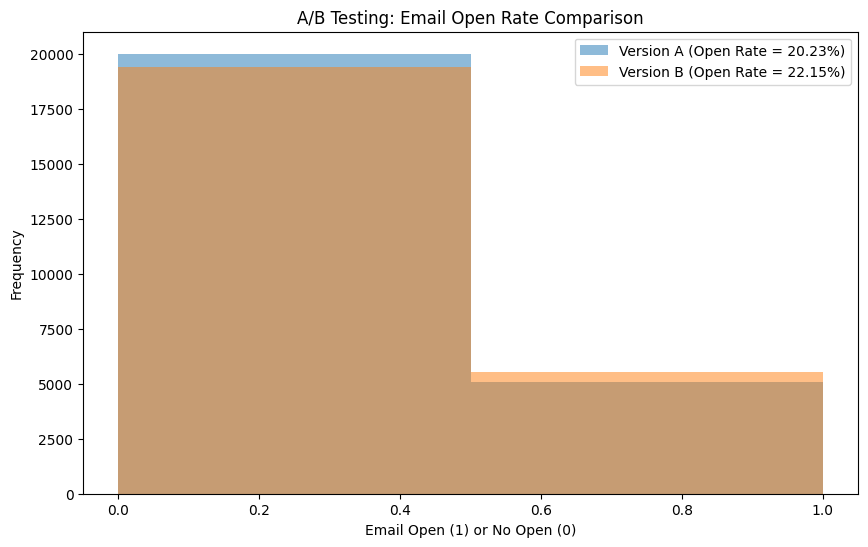

Results saved to 'ab_test_results_email_campaign.csv'.


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Step 1: Read the dataset from CSV file
data = pd.read_csv('ab_test_email_campaign_data.csv')

# Step 2: Preprocessing Data
# Filter data for each version
group_A_data = data[data['Email_Version'] == 'A']['Email_Open']
group_B_data = data[data['Email_Version'] == 'B']['Email_Open']

# Step 3: A/B Testing - Perform a Two-Sample t-test
# Calculate the conversion (open) rates
conversion_rate_A = group_A_data.mean()
conversion_rate_B = group_B_data.mean()

# Perform the two-sample t-test
t_stat, p_value = stats.ttest_ind(group_A_data, group_B_data)

# Display the results
print(f"Conversion rate for Version A: {conversion_rate_A:.4f}")
print(f"Conversion rate for Version B: {conversion_rate_B:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation of Results
if p_value < 0.05:
    print("The result is statistically significant, meaning there is a significant difference between A and B.")
else:
    print("The result is not statistically significant, meaning there is no significant difference between A and B.")

# Step 4: Visualize the Results
plt.figure(figsize=(10, 6))

# Plotting histograms for both groups
plt.hist(group_A_data, bins=2, alpha=0.5, label='Version A (Open Rate = {:.2f}%)'.format(conversion_rate_A * 100))
plt.hist(group_B_data, bins=2, alpha=0.5, label='Version B (Open Rate = {:.2f}%)'.format(conversion_rate_B * 100))

plt.title('A/B Testing: Email Open Rate Comparison')
plt.xlabel('Email Open (1) or No Open (0)')
plt.ylabel('Frequency')
plt.legend()

# Show plot
plt.show()

# Step 5: Save the DataFrame with results
data.to_csv('ab_test_results_email_campaign.csv', index=False)

print("Results saved to 'ab_test_results_email_campaign.csv'.")
